## Linear regression example

### Prepare data

In a federated linear regression, each local site transmits its sufficient statistics $(\mathbf{X}^\top \mathbf{X}, \mathbf{X}^\top \mathbf{y}, \mathbf{y}^\top \mathbf{y}, n)$ to the central server. Let's assume the central server collects these sufficient statistics in a nested list object called `sumstats`, each entry representing one local site and containing another list with entries `xx`, `xy`, `yy` and `n`.

As a demonstration, we will use the `nurses hom` synthetic test data set from the `confeR` package. It contains the (simulated) individual participant data (IPD) from 25 hospitals and the summary statistics transmitted by each hospital.

In [10]:
library(confeR)

data(nurses_hom, package = "confeR")
data <- nurses_hom$data_ipd
sumstats_hom <- nurses_hom$summary_stats_hom # using global intercept
sumstats_het <- nurses_hom$summary_stats_het # using local intercepts

sumstats <- sumstats_hom

# If true, use fixed-effects local intercepts for each site; else use one global intercept
use_local_intercepts <- identical(sumstats, sumstats_het)
cat("Use local intercepts:", use_local_intercepts)

Use local intercepts: FALSE

In [11]:
# Inspect the summary statistics from the first hospital
sumstats[[1]]

$xx
           Intercept       age    gender  wardtype experience
Intercept  41.000000  7.640903 22.000000 17.000000   4.306097
age         7.640903 32.596424  4.000946  6.870789   4.856068
gender     22.000000  4.000946 22.000000  9.000000   5.740959
wardtype   17.000000  6.870789  9.000000 17.000000  -2.179114
experience  4.306097  4.856068  5.740959 -2.179114  28.338100

$xy
                  [,1]
Intercept   -9.7900633
age          0.6060755
gender     -13.4555082
wardtype    -4.4388355
experience -18.2877613

$yy
         [,1]
[1,] 44.93776

$n
[1] 41

### Perform conjugate federated analysis

In [12]:
params_oneshot <- bca_oneshot(sumstats, use_local_intercepts, family="gaussian")
df_bca <- tidy_results(params_oneshot, use_local_intercepts)
df_bca

Method,Covariate,Estimate,lower,upper
<chr>,<chr>,<dbl>,<dbl>,<dbl>
BCA,(Intercept),0.43115092,0.3246986,0.5376032
BCA,age,0.26965614,0.2067120,0.3326003
BCA,gender,-0.54685291,-0.6715928,-0.4221130
BCA,wardtype,-0.01006702,-0.1351289,0.1149949
BCA,experience,-0.41573823,-0.4793343,-0.3521421
BCA,sigma2,1.01095221,0.9276831,1.1060180


### Reverse-Bayes predictive check

In [13]:
pred_results <- pred_check(params_oneshot,
                            sumstats,
                            family="gaussian",
                            use_local_intercepts,
                            remove_intercept = use_local_intercepts)

Loading required package: ggplot2

Loading required package: ggsci

Warning message in match(df_forest$site, p_box_df_right$site, nomatch = Inf):
“NAs introduced by coercion to integer range”


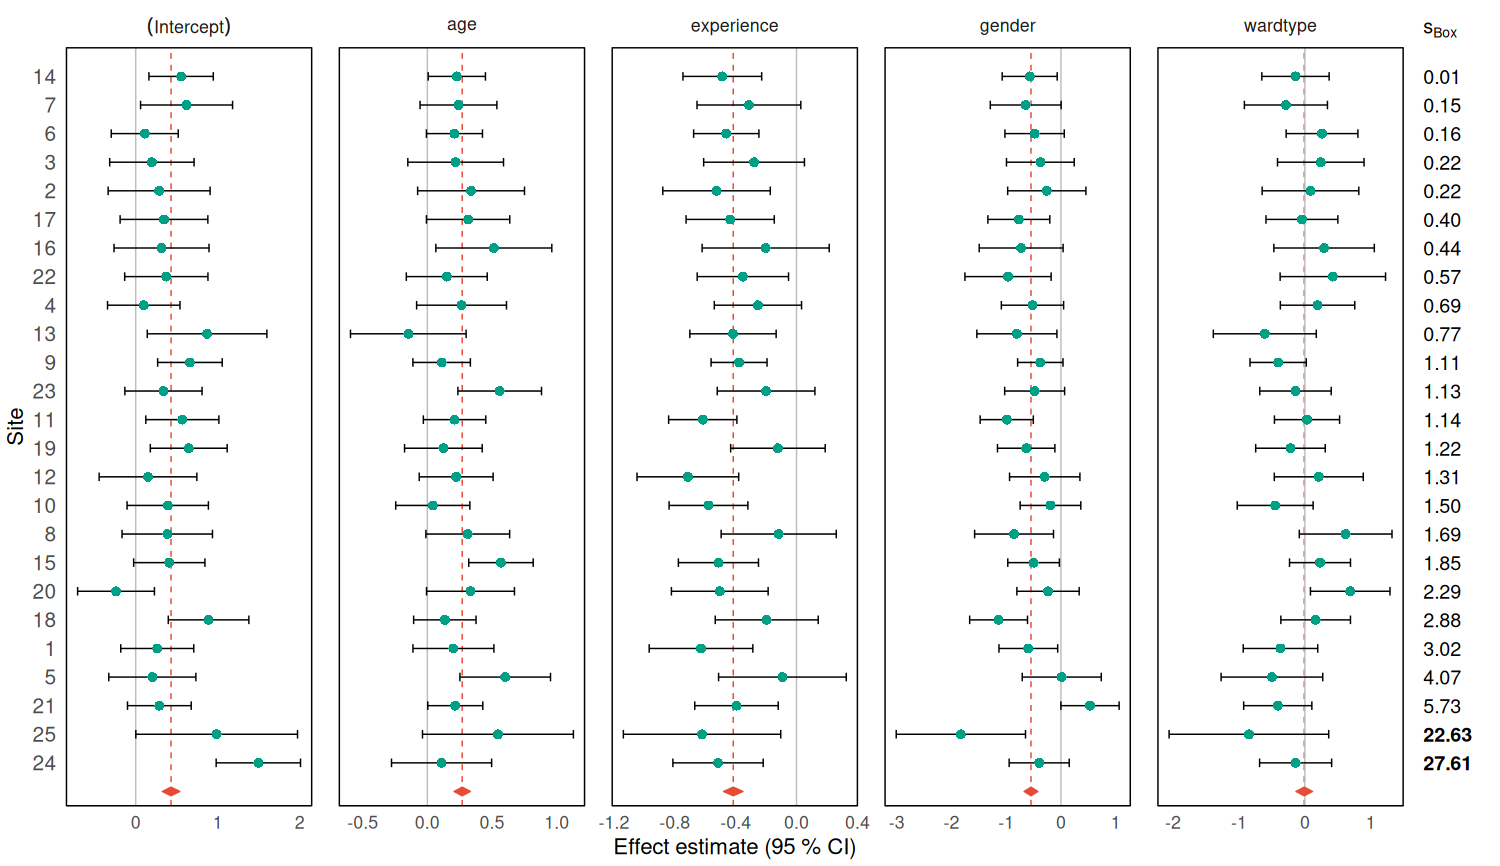

In [14]:
df_forest <- prepare_forest_plot(df_bca, sumstats, alpha=0.05, family="gaussian")
df_forest <- df_forest |> dplyr::filter(df_forest$Covariate != "sigma2")
forest_plot(df_forest, pred_results$pboxes, inline_plot = TRUE, use_log_scale = TRUE, order_box = )

Warning message in match(df_forest$site, p_box_df_right$site, nomatch = Inf):
“NAs introduced by coercion to integer range”


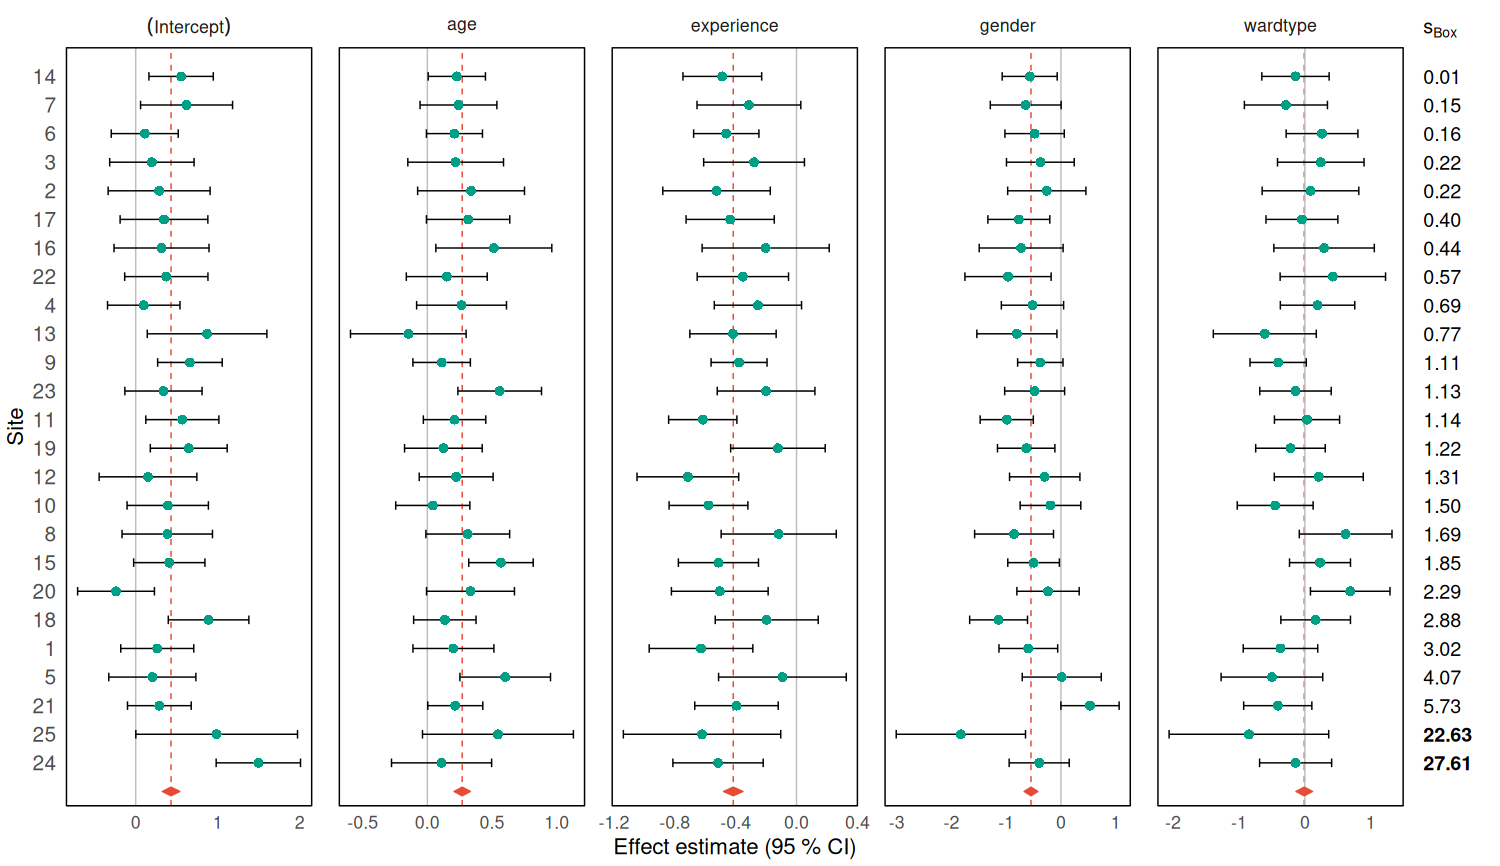

In [15]:
# Or use wrapper that computes sbox and makes forest plot in one call
forest_box(params_oneshot,
            sumstats,
            family="gaussian",
            use_local_intercepts=use_local_intercepts,
            remove_intercept=FALSE,
            alpha=0.05)

### Computing summary statistics from IPD

If, for whatever reason (e.g. when using synthetic data), IPD is available and you wish to compute the summary statistics for each local site, the code below can be used.

In [16]:
library(dplyr)

# name of the column representing the local site ID
center_name <- "hospital"

# model for lm() regression
model <- stress ~ gender + age + experience + wardtype

data_split <- data |>
  group_by(.data[[center_name]]) |>
  group_split()

outcome <- all.vars(model)[1]
covariates <- attr(terms(model), "term.labels")
sumstats <- lapply(seq_along(data_split), function(i) {
    bayes_lin_reg_stats(data_split[[i]], outcome, covariates,
                        k = if (use_local_intercepts) i else 0,
                        n_sites = length(data_split))
})


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## GLM regression example

In [12]:
# TO DO